# Part 1: EC2 and Spark setup

In [1]:
!pip3 install pyspark pandas==2.2.2 pyarrow

# Part 2: Start Spark

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NYC Taxi Analytics Assignment")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.hadoop.fs.s3a.connection.timeout", "60000")
    .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 00:34:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Part 3: Load yellow and green taxi data

In [3]:
yellow_df = spark.read.parquet("yellow_tripdata_2026-01.parquet")
green_df = spark.read.parquet("green_tripdata_2026-01.parquet")

In [4]:
yellow_df.printSchema()
green_df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)

root
 |-- VendorID: integer (nullable = true)
 |-- lpep_pickup_datetime: ti

In [5]:
yellow_df.show(5, truncate=False)
green_df.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|2       |2026-01-01 00:54:04 |2026-01-01 00:59:37  |1              |0.97         |1         |N                 |239         |238 

# Part 4: Standardize schemas

In [6]:
print((yellow_df.count(), len(yellow_df.columns)))
print((green_df.count(), len(green_df.columns)))

(3724889, 20)
(40272, 21)


In [7]:
yellow_df = yellow_df.withColumnsRenamed(dict([
    ("tpep_pickup_datetime", "pickup_datetime"),
    ("tpep_dropoff_datetime", "dropoff_datetime")
]))

green_df = green_df.withColumnsRenamed(dict([
    ("lpep_pickup_datetime", "pickup_datetime"),
    ("lpep_dropoff_datetime", "dropoff_datetime")
]))

In [8]:
from pyspark.sql.functions import lit

yellow_df = yellow_df.withColumn("taxi_type", lit("yellow"))
green_df = green_df.withColumn("taxi_type", lit("green"))

combined_df = yellow_df.unionByName(green_df, allowMissingColumns=True)
print((combined_df.count(), len(combined_df.columns))) # since Pyspark dfs don't have .shape attribute
combined_df.printSchema()

(3765161, 23)
root
 |-- VendorID: integer (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- taxi_type: string (nullable = false)
 |-- ehail_fee: double (nullab

# Part 5: Clean the data

In [9]:
# Remove rows with missing pickup or dropoff timestamps
combined_df = combined_df.filter(
    (combined_df["pickup_datetime"].isNotNull()) &
    (combined_df["dropoff_datetime"].isNotNull())
)
print((combined_df.count(), len(combined_df.columns)))

(3765161, 23)


In [10]:
# Remove trips with non-positive distance
combined_df = combined_df.filter(combined_df["trip_distance"] > 0)
print((combined_df.count(), len(combined_df.columns)))

(3638133, 23)


In [11]:
# Remove trips with negative fares
combined_df = combined_df.filter(combined_df["fare_amount"] >= 0)
print((combined_df.count(), len(combined_df.columns)))

(3601357, 23)


In [12]:
# Remove trips with negative total amount
combined_df = combined_df.filter(combined_df["total_amount"] >= 0)
print((combined_df.count(), len(combined_df.columns)))

(3600972, 23)


In [13]:
# Remove trips longer than 24 hours
from pyspark.sql.functions import unix_timestamp
combined_df = combined_df.filter(unix_timestamp(combined_df["dropoff_datetime"]) - unix_timestamp(combined_df["pickup_datetime"]) <= 24 * 3600)
print((combined_df.count(), len(combined_df.columns)))

(3600947, 23)


In [14]:
# Remove trips with drop-off time before pickup time
combined_df = combined_df.filter(combined_df["dropoff_datetime"] >= combined_df["pickup_datetime"])
print((combined_df.count(), len(combined_df.columns)))

(3600946, 23)


# Part 6: Required analytics

In [15]:
# Question 1: Which taxi type had more trips?
trip_counts = combined_df.groupBy("taxi_type").count()
trip_counts.show()

+---------+-------+
|taxi_type|  count|
+---------+-------+
|   yellow|3562033|
|    green|  38913|
+---------+-------+



In [16]:
# Question 2: What was the average fare by taxi type?
average_fare = combined_df.groupBy("taxi_type").avg("fare_amount")
average_fare.show()

+---------+------------------+
|taxi_type|  avg(fare_amount)|
+---------+------------------+
|   yellow|21.021527776420072|
|    green|16.004368719965075|
+---------+------------------+



In [17]:
# Question 3: What was the average trip distance by taxi type?
average_distance = combined_df.groupBy("taxi_type").avg("trip_distance")
average_distance.show()

+---------+------------------+
|taxi_type|avg(trip_distance)|
+---------+------------------+
|   yellow| 6.705125379241041|
|    green|12.988674221982372|
+---------+------------------+



In [18]:
# Question 4: What hour of day had the most pickups?
from pyspark.sql.functions import hour 

df = combined_df.withColumn("pickup_hour", hour(combined_df["pickup_datetime"]))
pickup_counts = df.groupBy("pickup_hour").count().orderBy("count", ascending=False)
pickup_counts.show()

+-----------+------+
|pickup_hour| count|
+-----------+------+
|         18|235765|
|         17|227332|
|         15|219306|
|         19|213794|
|         20|210273|
|         21|209653|
|         16|209371|
|         14|205223|
|         13|193716|
|         22|192096|
|         12|185623|
|         11|170266|
|         10|160406|
|          9|156308|
|         23|150074|
|          8|148023|
|          7|113377|
|          0|109932|
|          1| 76311|
|          6| 63194|
+-----------+------+
only showing top 20 rows


In [21]:
from pyspark.sql.functions import col, sum, when

combined_df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in combined_df.columns
]).show(truncate=False)

+--------+---------------+----------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+---------+---------+---------+
|VendorID|pickup_datetime|dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|taxi_type|ehail_fee|trip_type|
+--------+---------------+----------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+---------+---------+---------+
|0       |0              |0               |1000665        |0          

In [ ]:
# Question 8: Predict the fare amount using non-fare predictor columns.
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col

combined_df = combined_df.withColumn(
    "taxi_type",
    (col("taxi_type") == "yellow").cast("int")
)

feature_cols = combined_df.columns
feature_cols.remove("fare_amount") # target variable
feature_cols.remove("pickup_datetime") # non-numeric
feature_cols.remove("dropoff_datetime") # non-numeric
feature_cols.remove("store_and_fwd_flag") # unrelated
feature_cols.remove("ehail_fee") # too many missing values
feature_cols.remove("trip_type") # too many missing values
feature_cols.remove("total_amount") # too correlated with fare_amount
feature_cols.remove("extra") # directly included in total_amount
feature_cols.remove("mta_tax") # directly included in total_amount
feature_cols.remove("improvement_surcharge") # directly included in total_amount
feature_cols.remove("tolls_amount") # directly included in total_amount
feature_cols.remove("congestion_surcharge") # directly included in total_amount
feature_cols.remove("Airport_fee") # directly included in total_amount
feature_cols.remove("cbd_congestion_fee") # directly included in total_amount

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
data = assembler.transform(combined_df).select("features", "fare_amount")
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

rf = RandomForestRegressor(featuresCol="features", labelCol="fare_amount", numTrees=100, maxDepth=5)
model = rf.fit(train_data)
train_preds = model.transform(train_data)
test_preds = model.transform(test_data)

evaluator = RegressionEvaluator(labelCol="fare_amount", predictionCol="prediction", metricName="rmse")
train_rmse = evaluator.evaluate(train_preds)
test_rmse = evaluator.evaluate(test_preds)
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

26/05/24 23:17:22 WARN MemoryStore: Not enough space to cache rdd_362_1 in memory! (computed 96.1 MiB so far)
26/05/24 23:17:22 WARN BlockManager: Persisting block rdd_362_1 to disk instead.
26/05/24 23:17:30 WARN MemoryStore: Not enough space to cache rdd_362_0 in memory! (computed 42.6 MiB so far)
26/05/24 23:17:30 WARN BlockManager: Persisting block rdd_362_0 to disk instead.
26/05/24 23:17:53 WARN MemoryStore: Not enough space to cache rdd_362_0 in memory! (computed 149.4 MiB so far)
26/05/24 23:18:19 WARN MemoryStore: Not enough space to cache rdd_362_0 in memory! (computed 149.4 MiB so far)
26/05/24 23:18:50 WARN MemoryStore: Not enough space to cache rdd_362_0 in memory! (computed 149.4 MiB so far)
26/05/24 23:19:28 WARN MemoryStore: Not enough space to cache rdd_362_0 in memory! (computed 149.4 MiB so far)
26/05/24 23:20:25 WARN MemoryStore: Not enough space to cache rdd_362_0 in memory! (computed 149.4 MiB so far)


Train RMSE: 6.65
Test RMSE: 6.51


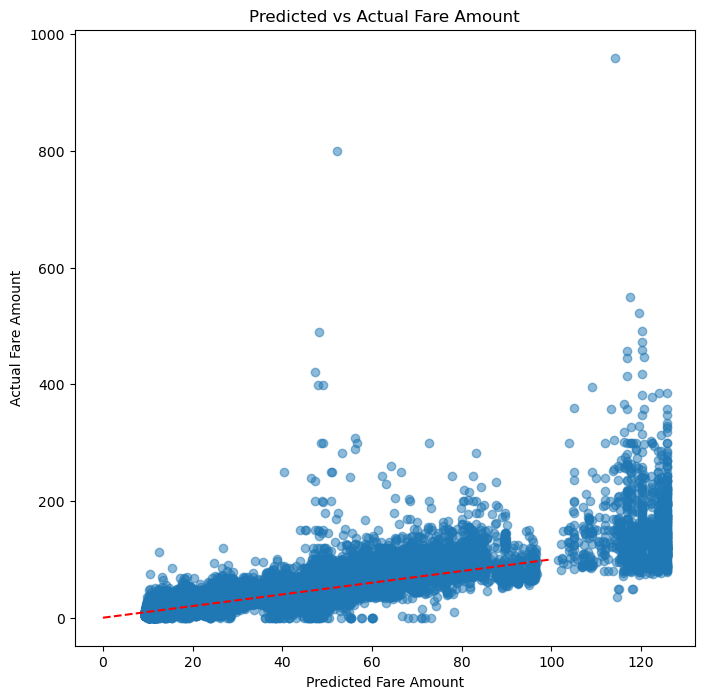

In [27]:
# Plot the predicted fare amount vs the actual fare amount. Save it as a .png and write to your S3 bucket. 
import matplotlib.pyplot as plt
import pandas as pd
preds_pd = test_preds.select("prediction", "fare_amount").toPandas()
plt.figure(figsize=(8, 8))
plt.scatter(preds_pd["prediction"], preds_pd["fare_amount"], alpha=0.5)
plt.plot([0, 100], [0, 100], color="red", linestyle="--")
plt.xlabel("Predicted Fare Amount")
plt.ylabel("Actual Fare Amount")
plt.title("Predicted vs Actual Fare Amount")
plt.savefig("work/predicted_vs_actual_fare.png")
plt.show()

In [29]:
import boto3 

s3 = boto3.client("s3")
BUCKET_NAME = "rosu-de300spring2026-bucket"
s3.upload_file("work/predicted_vs_actual_fare.png", BUCKET_NAME, "HW3/predicted_vs_actual_fare.png")

# Part 7: Write results to s3

In [ ]:
output_base = "work/"

trip_counts.write.mode("overwrite").parquet(f"{output_base}/trips_by_type")
average_fare.write.mode("overwrite").parquet(f"{output_base}/avg_fare_by_type")
average_distance.write.mode("overwrite").parquet(f"{output_base}/avg_distance_by_type")
pickup_counts.write.mode("overwrite").parquet(f"{output_base}/pickups_by_hour")

In [38]:
# PySpark write method did not work with S3 URL, using boto3 client instead
import os

for folder in ["trips_by_type", "avg_fare_by_type", "avg_distance_by_type", "pickups_by_hour"]:
    local_path = f"{output_base}/{folder}"
    for file in os.listdir(local_path):
        full_path = os.path.join(local_path, file)

        if os.path.isfile(full_path):
            s3.upload_file(
                full_path,
                BUCKET_NAME,
                f"HW3/{folder}/{file}"
            )